In [1]:
import tensorflow as tf

In [2]:
mnist=tf.keras.datasets.mnist

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253 159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 253 252 252  96 18

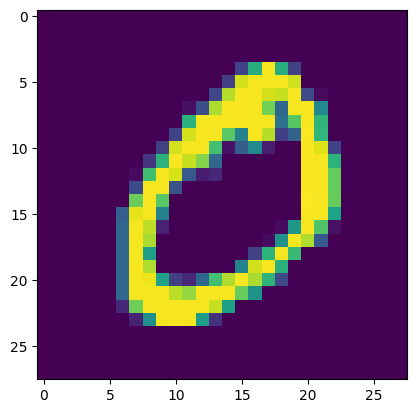

In [6]:
import numpy as np
np.set_printoptions(linewidth=200)
import matplotlib.pyplot as plt
plt .imshow(x_train[1])
print(x_train[1])
print(y_train[1])
print(x_train.shape)
print(x_test.shape)


In [7]:
x_train=x_train/255.0
x_test=x_test/255.0

In [8]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(512,activation=tf.nn.relu),
    tf.keras.layers.Dense(10,activation=tf.nn.softmax)
])

c:\Users\arbag\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epoch,logs={}):
        if(logs.get('accuracy')>0.99):
            print("\nReached 99% accuracy so cancelling training!")
            self.model.stop_training = True

In [12]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=20,verbose=2,callbacks=[myCallback()])

Epoch 1/20
1875/1875 - 7s - 3ms/step - accuracy: 0.9400 - loss: 0.2036
Epoch 2/20
1875/1875 - 7s - 3ms/step - accuracy: 0.9747 - loss: 0.0821
Epoch 3/20
1875/1875 - 8s - 5ms/step - accuracy: 0.9834 - loss: 0.0523
Epoch 4/20
1875/1875 - 5s - 3ms/step - accuracy: 0.9880 - loss: 0.0373
Epoch 5/20

Reached 99% accuracy so cancelling training!
1875/1875 - 7s - 3ms/step - accuracy: 0.9908 - loss: 0.0274


In [13]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9808 - loss: 0.0692


[0.06921090185642242, 0.9807999730110168]

In [16]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.40436232e-08, 2.20274501e-08, 3.74164628e-08, ..., 9.99964833e-01, 2.42233060e-08, 1.23762106e-06],
       [3.70911941e-08, 2.11195729e-05, 9.99978900e-01, ..., 1.60200770e-12, 2.13561435e-08, 9.32254118e-15],
       [3.35343153e-09, 9.99873281e-01, 2.74707727e-05, ..., 8.19144916e-05, 1.24876615e-05, 2.81718684e-08],
       ...,
       [2.28093310e-15, 2.90634189e-13, 6.88817222e-14, ..., 6.95823132e-08, 2.86943225e-09, 3.88779114e-07],
       [2.71450890e-10, 4.94580098e-14, 2.14078253e-13, ..., 7.04628911e-10, 4.28701023e-05, 8.96443903e-14],
       [1.71659575e-10, 1.06848624e-14, 5.61308899e-12, ..., 3.19320648e-16, 4.51543154e-13, 1.27019519e-14]], shape=(10000, 10), dtype=float32)